# Where does the extra low cloud in the KENDA-CH1 analysis come from?

## The problem

Total cloud cover (CLCT) from ICON-CH1 is biased too cloudy in the first hours of each forecast.
Verified against Swiss stations over autumn, the bias is about **+0.6 octa at lead time 1 h**,
settling to about **+0.15 octa by lead time 24 h**; the excess decays over roughly 4-6 hours.

The counter-intuitive part: the short-lead forecast is *better* on every other score — lower mean
absolute error, lower error standard deviation, higher correlation. Only the **bias** is worse. So
the assimilation is putting cloud in the right places at the right times while overdoing the
overall amount.

This notebook asks **where in the hourly assimilation cycle the extra cloud enters**, using two
experiments over 4-10 October 2025:

- **801** — operational-like reference, assimilates screen-level temperature and humidity
  (`T_2M`, `RH_2M`) among much else.
- **802** — identical but with `T_2M` and `RH_2M` withheld.

## How one hour of the cycle works

Every hour KENDA-CH1 repeats the same loop. The files it leaves behind are the stages of that loop:

| file | what it is |
|---|---|
| `lff<T>` | **background** — the model's own 1 h forecast from the previous cycle, valid at T, before any new observations are used |
| `inc<T>` | **increment** — the correction obtained by comparing background against observations. Corrections only, not a full state |
| `laf<T>` | **raw analysis** — background plus increment, applied instantly (`laf = lff + inc` exactly) |
| `iaf<T>` | **balanced analysis** — the same increment fed in gradually over a 10-minute window instead of all at once, to avoid shocking the model. This is what the next forecast starts from |
| `iff<T>` | the background 5 minutes earlier (valid at T-5 min): the start of that 10-minute window |

`lff`, `inc`, `laf` and `iaf` for a given `<T>` are all valid at the same time T. The next cycle's
background `lff<T+1>` is the 1 h forecast launched from `iaf<T>`, so the cycle closes.

The gradual-insertion window runs from **T-5 min to T+5 min**, centred on T. Two consequences worth
remembering: `iaf<T>` already contains about 10 minutes of model evolution on top of the increment,
and the forecast producing `lff<T+1>` is still being nudged for its first 5 of 60 minutes.

## The three steps we can separate

```
background          raw analysis        balanced analysis        next background
  lff(T)     --->     laf(T)      --->      iaf(T)        --->     lff(T+1)
          increment          settling               free run
          (no model)      (10 min model)          (1 h model)
```

| term | how it is computed | how much model is in it |
|---|---|---|
| `d_letkf` | `inc(T)` | **none** — pure observation-driven correction |
| `d_settle` | `iaf(T) - lff(T) - inc(T)` | gradual insertion plus ~10 min |
| `d_free` | `lff(T+1) - iaf(T)` | ~1 h |

**Sign convention throughout: positive means more cloud, more moisture, warmer.**

## What this notebook can and cannot answer

- **Cloud cover cannot be attributed cleanly.** Cloud cover is *diagnosed* — the model computes it
  from temperature, humidity and cloud water whenever needed. It is never analysed, so no
  cloud-cover increment exists. The earliest cloud-cover number after assimilation is `iaf`, which
  already has ~10 min of model in it.
- **Temperature, water vapour and cloud water can.** These are what the cloud-cover scheme is
  computed from, and all three are in the increment file. The three-way split above is exact for
  them, so mechanism arguments should be made on these and then related to cloud cover.
- **Cloud ice is untouched by the assimilation** — excluded both when the analysis is written and
  again when the model reads it. Any ice-cloud change is therefore model response by construction.
- **No observations appear anywhere in this notebook.** It can establish that assimilation adds
  cloud; it cannot say whether that is right or wrong. Deciding that needs the analysis itself
  verified against station observations, which is separate work.


## 0.1 Imports and configuration

In [1]:
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"  # must be set before importing earthkit.data

from datetime import datetime, timedelta
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import earthkit.data as ekd

SAVE_FIGURES = True     # write PNGs to OUTPUT_DIR
SHOW_FIGURES = True     # also draw them inline below each cell

# Only switch to the headless backend if we really want no output on screen
# (e.g. running this file as a batch script).
if SAVE_FIGURES and not SHOW_FIGURES:
    matplotlib.use("Agg")

PARALLEL = True     # section 1 only
MAX_WORKERS = 8

OUTPUT_DIR = Path("./figures/spindown_decomposition")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def finish(fig, name):
    """Save a figure and/or draw it inline.

    Closing before showing produces a blank cell, so only close when not showing.
    """
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / name, dpi=150, bbox_inches="tight")
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


In [2]:
# --- experiments ------------------------------------------------------------
EXP_IDS = ["801", "802"]   # 801 = reference; 802 = screen-level T/RH withheld
BASE_DIR_TMPL = "/store_new/mch/msopr/jdelbeke/ICON_TST/{exp}"
YEAR_SUFFIX = "25"         # -> FG25 / ANA25

# --- cycling window ---------------------------------------------------------
# Available on disk for both experiments: 2025-10-04 00/01 .. 2025-10-10 00/01.
# CYCLE_END is the last T for which lff(T+1) also exists, since every step needs it.
CYCLE_START = datetime(2025, 10, 4, 1)
CYCLE_END = datetime(2025, 10, 10, 0)
CYCLE_TIMES = pd.date_range(CYCLE_START, CYCLE_END, freq="1h").to_pydatetime().tolist()

# Hours used by the mechanism sections (3-6). Section 1 always uses every cycle.
#   list(range(7, 13))    -> 36 cycles/experiment. Morning window, where earlier
#                            verification found the largest 801-vs-802 difference.
#   list(range(0, 24, 3)) -> 48 cycles/experiment. Full diurnal coverage, recommended
#                            when the question is "does this depend on time of day".
#   list(range(24))       -> 144 cycles/experiment. Everything, several hours of runtime.
FOCUS_HOURS = list(range(4, 13))

# --- vertical range ---------------------------------------------------------
# ICON-CH1 has 80 model levels, numbered 1 at the model top and 80 at the ground.
# 40-80 covers the ground up to roughly the mid troposphere, which is where liquid
# cloud lives; it also keeps memory down (see the note in section 3).
LEVELS_OF_INTEREST = list(range(40, 81))

# --- optional throttles for a quick first pass; None/1 = no throttle ---------
MAX_FRAMES = None
FRAME_STRIDE = 1


## 0.2 Reading the files

Each GRIB file holds every variable and every model level as separate messages. These helpers build
a name-to-message index once per file, then pull out either a single-level field (such as total
cloud cover) or all levels of a 3-D field at once.


In [3]:
def file_path(exp_id, kind, time):
    """kind: "lff"/"iff" (first-guess archive) or "inc"/"iaf"/"laf" (analysis archive)."""
    base = BASE_DIR_TMPL.format(exp=exp_id)
    sub = ("FG" if kind in ("lff", "iff") else "ANA") + YEAR_SUFFIX
    return os.path.join(base, sub, "det", f"{kind}{time:%Y%m%d%H}")


def load_index(path):
    """Map variable name -> list of GRIB messages, in one pass over the file.

    earthkit's own fs.sel(shortName=...) returns an EMPTY result for these files rather
    than raising, so filtering on the metadata by hand is what actually works here.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    fields = list(ekd.from_source("file", path).to_fieldlist())
    index = {}
    for f in fields:
        index.setdefault(f.metadata("shortName"), []).append(f)
    return index


def field_value(index, short_name):
    """Single-level field -> (lon, lat, values)."""
    xa = index[short_name][0].to_xarray()
    return xa["longitude"].values, xa["latitude"].values, xa[short_name].values


def profile_value(index, short_name, levels=None):
    """Multi-level field -> (levels, lon, lat, array of shape (n_levels, n_cells)).

    Converting all levels in one call is about five times faster than one call per level.
    """
    xa = ekd.FieldList.from_fields(index[short_name]).to_xarray()
    lev = xa["level"].values
    order = np.argsort(lev)
    lev, arr = lev[order], xa[short_name].values[order]
    if levels is not None:
        keep = np.isin(lev, levels)
        lev, arr = lev[keep], arr[keep]
    return lev, xa["longitude"].values, xa["latitude"].values, arr


## 0.3 What the increment does and does not contain

The increment carries temperature, water vapour, cloud **water**, wind, pressure and soil moisture
— but **no cloud fraction and no cloud ice**.

Both omissions are deliberate configuration choices rather than gaps in the archive: cloud ice is
excluded when the analysis is written and ignored again when the model reads it. So:

- any change in cloud *cover* between background and analysis is a downstream response to the
  temperature, humidity and cloud-water corrections, never a direct correction of cloud cover;
- any change in cloud *ice* is model response only.

One further configuration detail matters for interpretation. Where the background already holds
cloud water, a cloud-water correction is added to cloud water as expected. Where the background is
cloud-free, the same correction is instead added to **water vapour**. That is a documented route by
which a correction intended as cloud arrives as invisible moisture, which the model may then
condense during the first timesteps.

(If this notebook is ever pointed at a different experiment, confirm these file contents still hold
before relying on the attribution below.)


## 1. Cloud cover through the cycle, every hour of the week

For every cycle, the domain-mean and regional-mean cloud cover at three stages: background,
balanced analysis, and the next background one hour later. Split into total, low, mid and high
cloud, because "extra cloud" means something quite different depending on the level — high cloud
counts towards the total but contributes little to what a surface station or a downward-longwave
measurement sees.

```
d_ana(T) = iaf(T)   - lff(T)     what the assimilation step adds
d_int(T) = lff(T+1) - iaf(T)     what the following hour does
```

**Important limitation of `d_int`.** The "next background" for cycle T *is* the background of cycle
T+1 — the same file. So summed over the week the two terms collapse to nothing more than the net
weather change:

```
mean(d_ana) + mean(d_int) = (last background - first background) / number of cycles
```

In a cycling system near equilibrium the following hour **must** remove whatever the assimilation
adds, otherwise cloud would grow without limit. So `d_int` being the mirror image of `d_ana` is
arithmetic, not a discovery, and it cannot be used as evidence that the model rejects or generates
cloud. What `d_ana` alone shows, and what the difference between the two experiments shows, is
informative.


In [4]:
CLOUD_VARS = ["CLCT", "CLCL", "CLCM", "CLCH"]

# Rough Swiss Plateau / Alpine split from terrain height and a bounding box. This is a
# geographical proxy, not the station-based classification used in routine verification,
# so treat the regional numbers as indicative.
PLATEAU_BOX = dict(lon=(6.0, 9.6), lat=(46.7, 47.6))
PLATEAU_MAX_HSURF = 800.0     # m
ALPINE_MIN_HSURF = 1500.0     # m

_region_mask_cache = {}


def region_masks(lon, lat, hsurf):
    """domain / plateau / alpine boolean masks. Cached: the grid never changes."""
    key = lon.tobytes()
    if key in _region_mask_cache:
        return _region_mask_cache[key]
    in_box = ((lon >= PLATEAU_BOX["lon"][0]) & (lon <= PLATEAU_BOX["lon"][1]) &
              (lat >= PLATEAU_BOX["lat"][0]) & (lat <= PLATEAU_BOX["lat"][1]))
    masks = {"domain": np.ones_like(hsurf, dtype=bool),
             "plateau": in_box & (hsurf <= PLATEAU_MAX_HSURF),
             "alpine": hsurf >= ALPINE_MIN_HSURF}
    _region_mask_cache[key] = masks
    return masks


In [5]:
def cycle_row(exp_id, t):
    """Regional-mean cloud cover at the three stages of one cycle."""
    lff_t = load_index(file_path(exp_id, "lff", t))
    iaf_t = load_index(file_path(exp_id, "iaf", t))
    lff_t1 = load_index(file_path(exp_id, "lff", t + timedelta(hours=1)))

    lon, lat, hsurf = field_value(lff_t, "HSURF")
    masks = region_masks(lon, lat, hsurf)

    row = dict(exp=exp_id, time=t, hour=t.hour)
    for var in CLOUD_VARS:
        _, _, v_lff = field_value(lff_t, var)
        _, _, v_iaf = field_value(iaf_t, var)
        _, _, v_lff1 = field_value(lff_t1, var)
        for region, mask in masks.items():
            row[f"{var}_lff_{region}"] = np.nanmean(v_lff[mask])
            row[f"{var}_iaf_{region}"] = np.nanmean(v_iaf[mask])
            row[f"{var}_lff1_{region}"] = np.nanmean(v_lff1[mask])
    return row


def cycle_row_safe(exp_id, t):
    try:
        return cycle_row(exp_id, t)
    except Exception as e:
        print(f"  skipped {exp_id} {t}: {e}")
        return None


In [6]:
times = CYCLE_TIMES[::FRAME_STRIDE]
if MAX_FRAMES is not None:
    times = times[:MAX_FRAMES]

jobs = [(exp_id, t) for exp_id in EXP_IDS for t in times]
rows = []
if PARALLEL:
    with ProcessPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futures = {ex.submit(cycle_row_safe, exp_id, t): (exp_id, t) for exp_id, t in jobs}
        for fut in as_completed(futures):
            r = fut.result()
            if r is not None:
                rows.append(r)
else:
    rows = [r for r in (cycle_row_safe(e, t) for e, t in jobs) if r is not None]

cycle_df = pd.DataFrame(rows).sort_values(["exp", "time"]).reset_index(drop=True)
cycle_df.to_csv(OUTPUT_DIR / "cycle_decomposition.csv", index=False)
print(f"{len(cycle_df)} cycle-experiment combinations loaded, of {len(jobs)} attempted")
cycle_df.head()


288 cycle-experiment combinations loaded, of 288 attempted


,exp,time,hour,CLCT_lff_domain,CLCT_iaf_domain,CLCT_lff1_domain,CLCT_lff_plateau,CLCT_iaf_plateau,CLCT_lff1_plateau,CLCT_lff_alpine,...,CLCM_lff1_alpine,CLCH_lff_domain,CLCH_iaf_domain,CLCH_lff1_domain,CLCH_lff_plateau,CLCH_iaf_plateau,CLCH_lff1_plateau,CLCH_lff_alpine,CLCH_iaf_alpine,CLCH_lff1_alpine
0,801,2025-10-04 01:00:00,1,71.058474,71.715900,71.691473,97.166629,98.154480,98.705846,72.281871,...,45.788407,47.701044,48.705670,45.741766,39.930362,52.087184,77.422744,41.487572,41.686325,40.528537
1,801,2025-10-04 02:00:00,2,71.691473,71.659577,75.055636,98.705846,98.718258,98.515255,73.409149,...,49.003034,45.741766,45.784455,44.099998,77.422744,78.452578,68.913236,40.528537,41.459660,31.403129
2,801,2025-10-04 03:00:00,3,75.055636,75.494090,75.749045,98.515255,98.634288,96.182613,75.719084,...,57.394635,44.099998,43.378732,38.020814,68.913236,67.316505,60.841748,31.403129,31.956640,25.252942
3,801,2025-10-04 04:00:00,4,75.749045,75.088289,73.076766,96.182613,95.237324,91.652653,78.865750,...,51.241957,38.020814,36.834996,31.410594,60.841748,55.190475,34.517516,25.252942,26.996650,23.952969
4,801,2025-10-04 05:00:00,5,73.076766,74.142224,72.488159,91.652653,90.098120,82.059178,74.128497,...,49.715678,31.410594,33.214240,31.157886,34.517516,33.020856,6.964064,23.952969,28.006219,42.086445


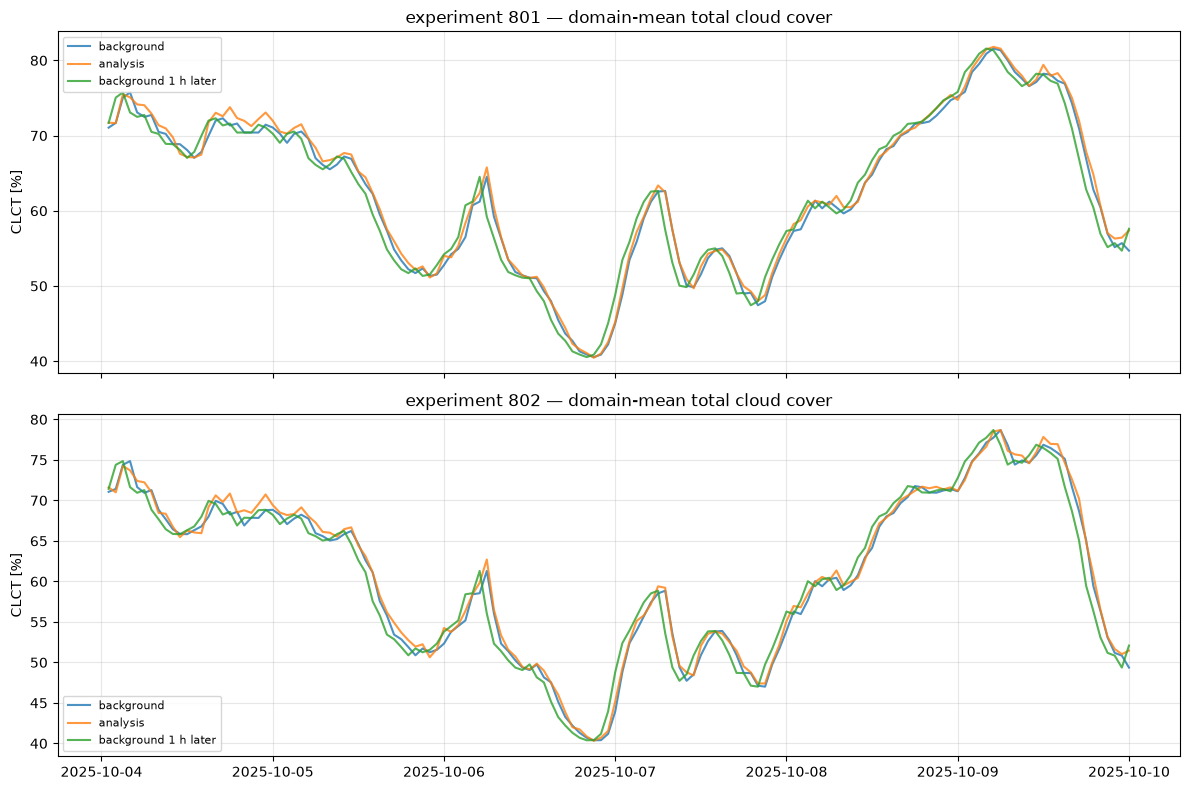

In [7]:
# Domain-mean total cloud cover at the three stages. The week-long swings are weather;
# what matters is the small persistent offset between the lines.
fig, axes = plt.subplots(len(EXP_IDS), 1, figsize=(12, 4 * len(EXP_IDS)), sharex=True)
for ax, exp_id in zip(np.atleast_1d(axes), EXP_IDS):
    sub = cycle_df[cycle_df["exp"] == exp_id].sort_values("time")
    ax.plot(sub["time"], sub["CLCT_lff_domain"], label="background", alpha=0.8)
    ax.plot(sub["time"], sub["CLCT_iaf_domain"], label="analysis", alpha=0.8)
    ax.plot(sub["time"], sub["CLCT_lff1_domain"], label="background 1 h later", alpha=0.8)
    ax.set_title(f"experiment {exp_id} — domain-mean total cloud cover")
    ax.set_ylabel("CLCT [%]")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
finish(fig, "clct_timeseries_domain.png")


In [8]:
# Mean and standard error of the two steps, per experiment / cloud type / region.
records = []
for exp_id in EXP_IDS:
    sub = cycle_df[cycle_df["exp"] == exp_id]
    for var in CLOUD_VARS:
        for region in ("domain", "plateau", "alpine"):
            d_ana = sub[f"{var}_iaf_{region}"] - sub[f"{var}_lff_{region}"]
            d_int = sub[f"{var}_lff1_{region}"] - sub[f"{var}_iaf_{region}"]
            records.append(dict(
                exp=exp_id, var=var, region=region,
                d_ana_mean=d_ana.mean(), d_ana_se=d_ana.sem(),
                d_int_mean=d_int.mean(), d_int_se=d_int.sem(),
                n=d_ana.notna().sum()))
decomposition_table = pd.DataFrame(records)
decomposition_table.to_csv(OUTPUT_DIR / "decomposition_table.csv", index=False)
decomposition_table


,exp,var,region,d_ana_mean,d_ana_se,d_int_mean,d_int_se,n
0,801,CLCT,domain,0.533483,0.051676,-0.626938,0.152675,144
1,801,CLCT,plateau,0.929070,0.231334,-1.091428,0.570330,144
2,801,CLCT,alpine,0.282230,0.110608,-0.536533,0.376670,144
3,801,CLCL,domain,0.778453,0.055471,-0.767755,0.137883,144
4,801,CLCL,plateau,2.125050,0.276025,-1.898264,0.511750,144
5,801,CLCL,alpine,0.246112,0.091406,-0.288910,0.219362,144
6,801,CLCM,domain,0.020433,0.050939,-0.167840,0.109701,144
7,801,CLCM,plateau,-0.089543,0.308219,-0.561975,0.787375,144
8,801,CLCM,alpine,-0.021622,0.107285,-0.248654,0.370114,144
9,801,CLCH,domain,0.280268,0.048415,-0.466895,0.203855,144


Compare the mean against its standard error to judge whether an offset is systematic or just
weather noise, and compare the cloud types against each other: a signal that lives in low cloud
implies a near-surface moisture problem, whereas one in high cloud does not and would also be hard
to reconcile with a deficit in downward longwave radiation at the ground.


## 2. Withholding screen-level temperature and humidity: 801 against 802

Experiment 802 withholds `T_2M` and `RH_2M`. Routine verification found the cloud-cover difference
between the two largest between 07 and 12 UTC and over the Plateau, so the same window is isolated
here. If the difference sits in the assimilation step it points at the screen-level observations
directly; if it also shows in the following hour, something else is involved.


In [9]:
morning = cycle_df[cycle_df["hour"].isin(FOCUS_HOURS)]

rows = []
for exp_id in EXP_IDS:
    sub = morning[morning["exp"] == exp_id]
    for region in ("domain", "plateau", "alpine"):
        d_ana = sub[f"CLCT_iaf_{region}"] - sub[f"CLCT_lff_{region}"]
        d_int = sub[f"CLCT_lff1_{region}"] - sub[f"CLCT_iaf_{region}"]
        rows.append(dict(exp=exp_id, region=region,
                         d_ana_mean=d_ana.mean(), d_ana_se=d_ana.sem(),
                         d_int_mean=d_int.mean(), d_int_se=d_int.sem(),
                         n=d_ana.notna().sum()))
morning_table = pd.DataFrame(rows)
morning_table.to_csv(OUTPUT_DIR / "morning_801_802_table.csv", index=False)
morning_table


,exp,region,d_ana_mean,d_ana_se,d_int_mean,d_int_se,n
0,801,domain,0.426811,0.080949,-0.947200,0.244428,54
1,801,plateau,0.472446,0.401378,-1.040703,0.628714,54
2,801,alpine,0.112587,0.230227,-0.644453,0.721445,54
3,802,domain,0.376737,0.080477,-0.743691,0.243430,54
4,802,plateau,1.095968,0.537390,-0.877218,0.884225,54
5,802,alpine,0.219580,0.208070,-0.639200,0.716594,54


Note that both experiments drift apart over the week, so each one's assimilation step is measured
against its own, by then different, background. The *absolute* difference in cloud cover between
the two experiments is the more robust comparison, and it is the one that reflects how much cloud
the screen-level observations sustain in the long run.


## 3. Splitting the cycle on temperature, water vapour and cloud water

Cloud cover on its own cannot identify a cause: it is a diagnosed quantity, two steps removed from
anything the assimilation touches. Temperature, water vapour and cloud water are what the
cloud-cover scheme is actually computed from, and all three are in the increment file — together
with pressure, so relative humidity can be formed at every stage as well.

That makes the three-way split exact for these variables:

| term | how it is computed | model content |
|---|---|---|
| `d_letkf` | the increment | none |
| `d_settle` | analysis minus background minus increment | gradual insertion plus ~10 min |
| `d_free` | next background minus analysis | ~1 h |

The raw analysis is reconstructed as background plus increment rather than read from disk, which is
exact and saves a file read per cycle. Relative humidity differences are formed by differencing the
relative humidity of each stage, not from the temperature and humidity increments, because relative
humidity is non-linear in both.

Cloud ice is deliberately absent from the increment, so its `d_letkf` is identically zero and the
split says nothing about ice cloud.

**Cost.** This section reads full 3-D fields: about 8 s per file, four files per cycle, of which one
is reused from the previous cycle. Peak memory is roughly 10 GB. With `FOCUS_HOURS` as the 07-12
window that is around half an hour for both experiments; every hour of the day would be several
hours. Set `MAX_FRAMES` to a small number for a quick check first.


In [10]:
# The variables the cloud-cover scheme is computed from, and which the increment carries.
DIAG_VARS = ["T", "QV", "QC"]
STAGES = ["lff", "laf", "iaf", "lff1"]           # the four states
TERMS = ["d_letkf", "d_settle", "d_free"]        # the three steps between them

STAGE_STYLE = {"lff": ("--", "background"), "laf": ("-", "raw analysis"),
               "iaf": ("-.", "balanced analysis"), "lff1": (":", "background 1 h later")}
TERM_STYLE = {"d_letkf": ("-", "increment (no model)"),
              "d_settle": ("--", "settling (~10 min model)"),
              "d_free": (":", "free run (1 h model)")}

LEVEL_LABEL = "model level   (80 = ground, 40 = mid troposphere)"


def orient_vertical(ax, level):
    """Ground at the bottom of the axis, model top at the top.

    Deliberately set_ylim and not invert_yaxis(): invert_yaxis() *toggles*, and with
    sharey=True all panels share one axis, so calling it once per panel flips an even
    number of times and silently lands back upside down.
    """
    ax.set_ylim(np.max(level), np.min(level))


def saturation_qv(T_k, p_pa):
    """Saturation specific humidity from temperature [K] and pressure [Pa] (Tetens, over water)."""
    T_c = T_k - 273.15
    e_s = 611.2 * np.exp(17.62 * T_c / (243.12 + T_c))          # saturation vapour pressure [Pa]
    return 0.622 * e_s / np.clip(p_pa - 0.378 * e_s, 1.0, None)


_index_cache = {}


def load_index_cached(path, max_entries=6):
    """load_index with a small cache, so lff(T+1) is reused as the next cycle's lff(T)."""
    if path in _index_cache:
        return _index_cache[path]
    index = load_index(path)
    if len(_index_cache) >= max_entries:
        _index_cache.pop(next(iter(_index_cache)))
    _index_cache[path] = index
    return index


def cycle_states(exp_id, t, levels=LEVELS_OF_INTEREST):
    """The four states and three steps of one cycle, for T, QV, QC and derived RH.

    Returns a dict keyed by (stage_or_term, variable) -> array (n_levels, n_cells), plus
    the level numbers, the region masks, the mass of each layer (for column integrals)
    and the geometry needed by the cross-sections in section 6.
    """
    lff = load_index_cached(file_path(exp_id, "lff", t))
    inc = load_index_cached(file_path(exp_id, "inc", t))
    iaf = load_index_cached(file_path(exp_id, "iaf", t))
    lff1 = load_index_cached(file_path(exp_id, "lff", t + timedelta(hours=1)))

    out = {}
    level = None
    for var in DIAG_VARS + ["P"]:
        level, _, _, a_lff = profile_value(lff, var, levels)
        _, _, _, a_inc = profile_value(inc, var, levels)
        _, _, _, a_iaf = profile_value(iaf, var, levels)
        _, _, _, a_lff1 = profile_value(lff1, var, levels)
        out[("lff", var)] = a_lff
        out[("laf", var)] = a_lff + a_inc          # exact: the raw analysis is background + increment
        out[("iaf", var)] = a_iaf
        out[("lff1", var)] = a_lff1
        if var != "P":         # pressure is only a stepping stone to RH; its steps are unused
            out[("d_letkf", var)] = a_inc
            out[("d_settle", var)] = a_iaf - a_lff - a_inc
            out[("d_free", var)] = a_lff1 - a_iaf
    out["level"] = level

    # Relative humidity per stage, then difference the stages.
    for stage in STAGES:
        out[(stage, "RH")] = 100.0 * out[(stage, "QV")] / saturation_qv(out[(stage, "T")],
                                                                       out[(stage, "P")])
    for term, (a, b) in zip(TERMS, [("laf", "lff"), ("iaf", "laf"), ("lff1", "iaf")]):
        out[(term, "RH")] = out[(a, "RH")] - out[(b, "RH")]
    for stage in STAGES:       # pressure no longer needed; free ~2.5 GB
        del out[(stage, "P")]

    # Mass of each layer, for column integrals. Density and level heights are only
    # carried in the analysis file.
    lev_hhl, lon, lat, hhl = profile_value(iaf, "HHL")    # 81 layer interfaces, top -> ground
    lev_den, _, _, den = profile_value(iaf, "DEN", levels)
    dz = -np.diff(hhl, axis=0)          # thickness of each of the 80 layers [m]
    out["layer_mass"] = den * dz[lev_den - 1]              # kg/m2 per layer

    _, _, hsurf = field_value(lff, "HSURF")
    out["masks"] = region_masks(lon, lat, hsurf)

    # Geometry for section 6: height of each level as the midpoint of its interfaces,
    # so cross-sections can be drawn against real altitude.
    out["lon"], out["lat"], out["hsurf"] = lon, lat, hsurf
    out["z"] = (0.5 * (hhl[:-1] + hhl[1:]))[lev_den - 1]
    return out


In [11]:
focus_times = [t for t in CYCLE_TIMES if t.hour in FOCUS_HOURS]
if MAX_FRAMES is not None:
    focus_times = focus_times[:MAX_FRAMES]

PLOT_VARS = DIAG_VARS + ["RH"]

state_profiles = {}   # (exp, stage, var) -> domain-mean profile per cycle
term_profiles = {}    # (exp, term, var)  -> domain-mean profile per cycle
supersat_frac = {}    # (exp, stage)      -> fraction of columns at/above saturation, per level
column_rows = []      # per cycle and region: column-integrated cloud water / vapour budget
levels_seen = None

print(f"{len(focus_times)} cycles x {len(EXP_IDS)} experiments; "
      f"roughly {len(focus_times) * len(EXP_IDS) * 3 * 8 / 60:.0f} min of reading")

for exp_id in EXP_IDS:
    for i, t in enumerate(focus_times):
        try:
            st = cycle_states(exp_id, t)
        except Exception as e:
            print(f"  skipped {exp_id} {t}: {e}")
            continue
        levels_seen = st["level"]

        for var in PLOT_VARS:
            for stage in STAGES:
                state_profiles.setdefault((exp_id, stage, var), []).append(
                    np.nanmean(st[(stage, var)], axis=1))
            for term in TERMS:
                term_profiles.setdefault((exp_id, term, var), []).append(
                    np.nanmean(st[(term, var)], axis=1))
        for stage in STAGES:
            supersat_frac.setdefault((exp_id, stage), []).append(
                np.nanmean(st[(stage, "RH")] >= 100.0, axis=1))

        # How much water each step adds to or removes from the column, in kg/m2
        for region, mask in st["masks"].items():
            row = dict(exp=exp_id, time=t, hour=t.hour, region=region)
            for var in ("QC", "QV"):
                for term in TERMS:
                    col = np.nansum(st[(term, var)] * st["layer_mass"], axis=0)
                    row[f"{var}_{term}"] = np.nanmean(col[mask])
            column_rows.append(row)

        if (i + 1) % 6 == 0:
            print(f"  {exp_id}: {i + 1}/{len(focus_times)}", flush=True)

state_profiles = {k: (levels_seen, np.mean(v, axis=0)) for k, v in state_profiles.items()}
term_profiles = {k: (levels_seen, np.mean(v, axis=0)) for k, v in term_profiles.items()}
supersat_frac = {k: (levels_seen, np.mean(v, axis=0)) for k, v in supersat_frac.items()}

column_df = pd.DataFrame(column_rows)
column_df.to_csv(OUTPUT_DIR / "moisture_budget_columns.csv", index=False)
print(f"\n{len(column_df)} region-cycle rows written")


54 cycles x 2 experiments; roughly 43 min of reading
  801: 6/54
  801: 12/54
  801: 18/54
  801: 24/54
  801: 30/54
  801: 36/54
  801: 42/54
  801: 48/54
  801: 54/54
  802: 6/54
  802: 12/54
  802: 18/54
  802: 24/54
  802: 30/54
  802: 36/54
  802: 42/54
  802: 48/54
  802: 54/54

324 region-cycle rows written


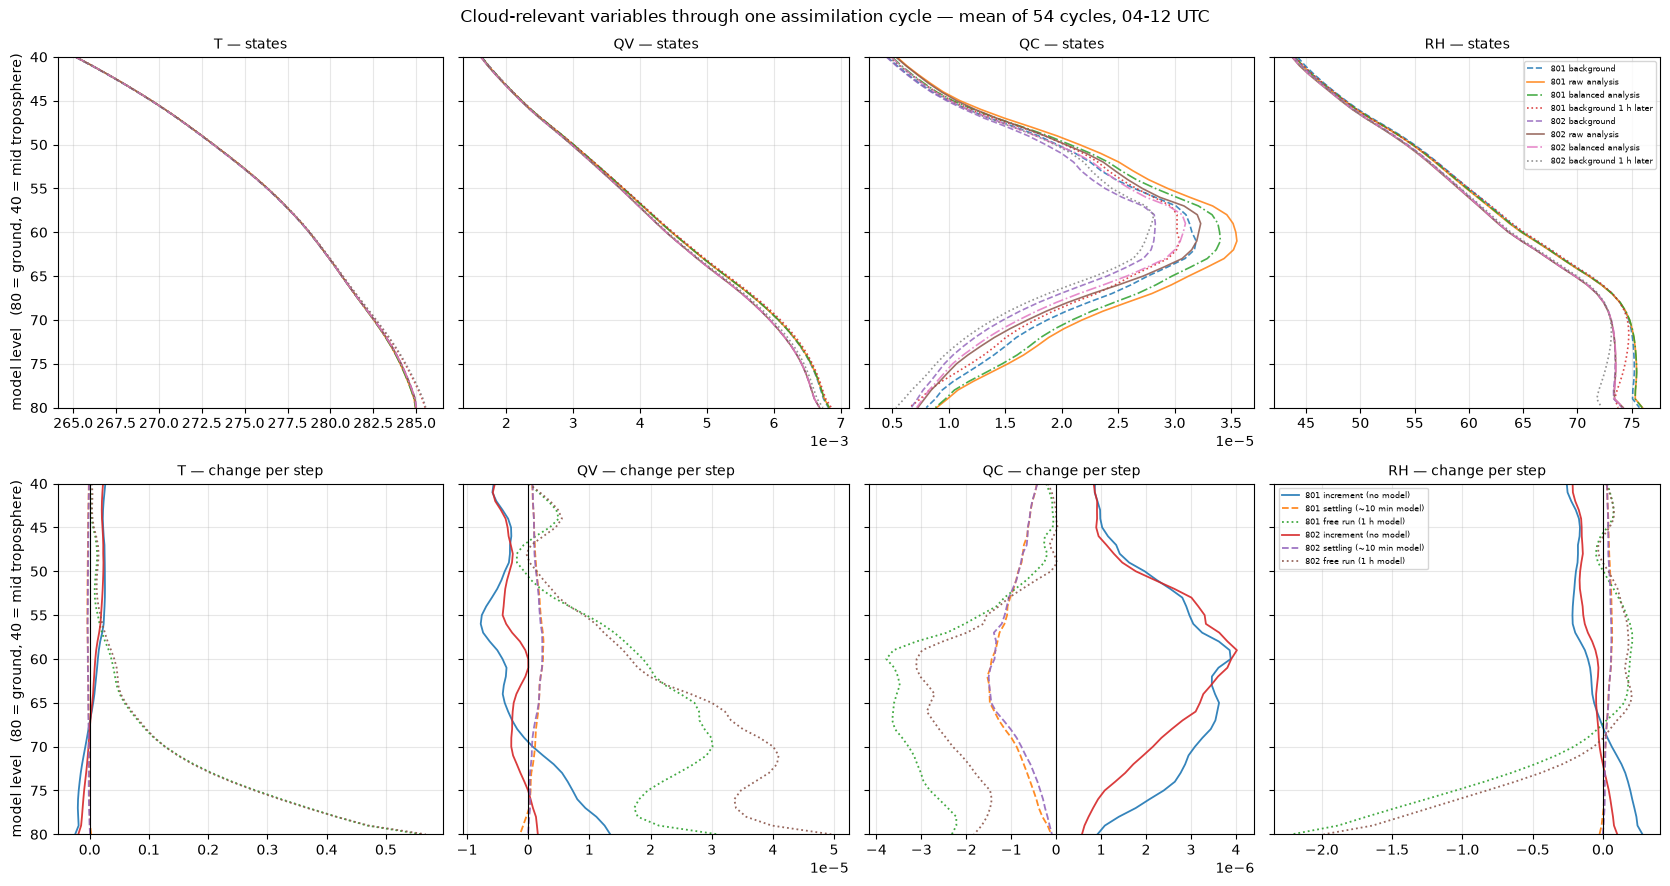

In [12]:
# Top row: the states. Bottom row: the three steps, which is where the separation lives.
fig, axes = plt.subplots(2, len(PLOT_VARS), figsize=(4.2 * len(PLOT_VARS), 9), sharey=True)

for col, var in enumerate(PLOT_VARS):
    ax = axes[0, col]
    for exp_id in EXP_IDS:
        for stage, (style, lab) in STAGE_STYLE.items():
            level, prof = state_profiles[(exp_id, stage, var)]
            ax.plot(prof, level, style, lw=1.2, alpha=0.85, label=f"{exp_id} {lab}")
    ax.set_title(f"{var} — states", fontsize=10)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3), axis="x")
    orient_vertical(ax, level)

    ax = axes[1, col]
    for exp_id in EXP_IDS:
        for term, (style, lab) in TERM_STYLE.items():
            level, prof = term_profiles[(exp_id, term, var)]
            ax.plot(prof, level, style, lw=1.3, alpha=0.9, label=f"{exp_id} {lab}")
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"{var} — change per step", fontsize=10)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3), axis="x")
    orient_vertical(ax, level)

for ax in (axes[0, 0], axes[1, 0]):
    ax.set_ylabel(LEVEL_LABEL)
axes[0, -1].legend(fontsize=6, loc="best")
axes[1, -1].legend(fontsize=6, loc="best")
plt.suptitle(f"Cloud-relevant variables through one assimilation cycle — "
             f"mean of {len(focus_times)} cycles, {min(FOCUS_HOURS):02d}-{max(FOCUS_HOURS):02d} UTC")
plt.tight_layout()
finish(fig, "diag_vars_three_way_split.png")


In [13]:
# Column-integrated water budget: how much each step puts in or takes out, per region.
budget = (column_df
          .melt(id_vars=["exp", "time", "hour", "region"], var_name="key", value_name="kg_m2")
          .assign(var=lambda d: d["key"].str.split("_").str[0],
                  term=lambda d: d["key"].str.split("_", n=1).str[1])
          .groupby(["exp", "region", "var", "term"])["kg_m2"]
          .agg(["mean", "sem", "count"])
          .reset_index())
budget.to_csv(OUTPUT_DIR / "moisture_budget_table.csv", index=False)
budget


,exp,region,var,term,mean,sem,count
0,801,alpine,QC,d_free,-0.001140,0.001298,54
1,801,alpine,QC,d_letkf,0.000553,0.000744,54
2,801,alpine,QC,d_settle,-0.000324,0.000134,54
3,801,alpine,QV,d_free,0.086051,0.023996,54
4,801,alpine,QV,d_letkf,-0.018341,0.009992,54
5,801,alpine,QV,d_settle,0.002805,0.000317,54
6,801,domain,QC,d_free,-0.007731,0.001804,54
7,801,domain,QC,d_letkf,0.009875,0.001369,54
8,801,domain,QC,d_settle,-0.003788,0.000483,54
9,801,domain,QV,d_free,0.040553,0.026151,54


Read the budget as a chain: how much cloud water the increment adds, how much of it survives the
gradual insertion, and how much is left after an hour. Comparing the cloud-water and water-vapour
rows of the same step shows whether the assimilation is moving water between the two phases or
adding it overall.


## 4. Does the assimilation push air past saturation?

The mechanism most often suspected is that correcting screen-level temperature and humidity lifts
part of the near-surface air past saturation, so the model condenses it into cloud within the first
timesteps.

Because the increment is available, this can be tested with no model involvement at all: compare the
fraction of columns at or above saturation in the background against the same fraction in the raw
analysis. Any difference between those two is the assimilation alone. The balanced analysis and the
following hour then show what the model does with it.

This counts grid-scale saturation only, which is a lower bound on where cloud appears — the scheme
also produces partial cloud below 100% relative humidity from sub-grid variability.


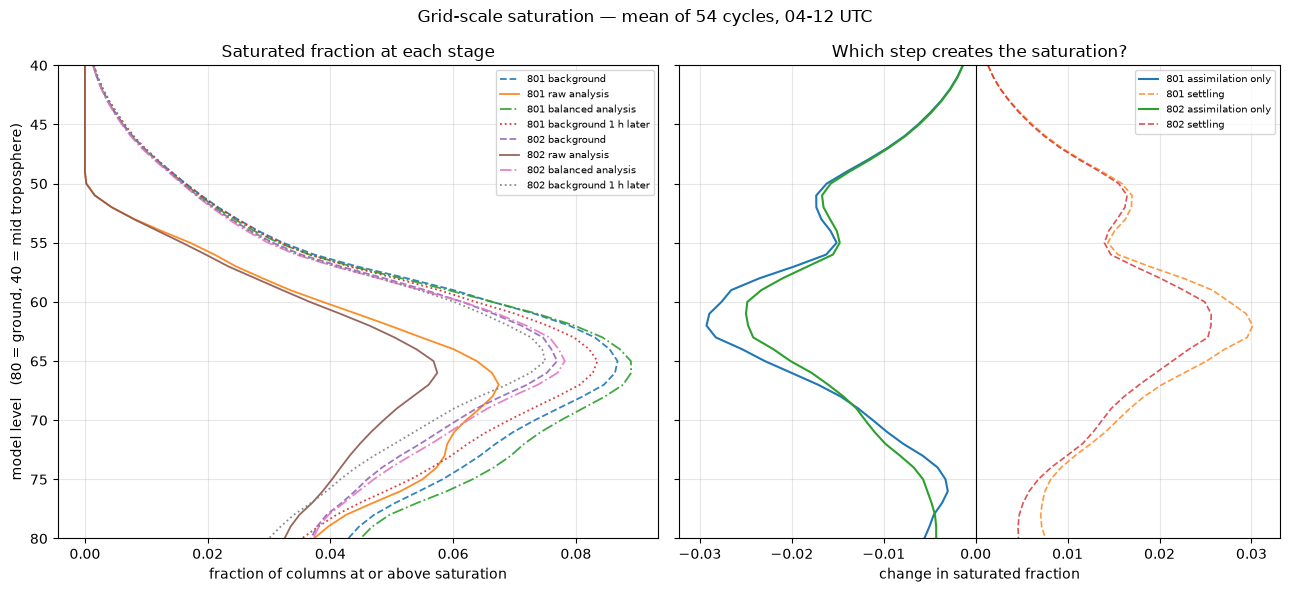

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for exp_id in EXP_IDS:
    for stage, (style, lab) in STAGE_STYLE.items():
        level, frac = supersat_frac[(exp_id, stage)]
        axes[0].plot(frac, level, style, lw=1.3, alpha=0.9, label=f"{exp_id} {lab}")
axes[0].set_xlabel("fraction of columns at or above saturation")
axes[0].set_ylabel(LEVEL_LABEL)
axes[0].set_title("Saturated fraction at each stage")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

# The assimilation-only contribution, with no model in it: raw analysis minus background.
for exp_id in EXP_IDS:
    level, f_lff = supersat_frac[(exp_id, "lff")]
    _, f_laf = supersat_frac[(exp_id, "laf")]
    _, f_iaf = supersat_frac[(exp_id, "iaf")]
    axes[1].plot(f_laf - f_lff, level, "-", lw=1.5, label=f"{exp_id} assimilation only")
    axes[1].plot(f_iaf - f_laf, level, "--", lw=1.2, alpha=0.8, label=f"{exp_id} settling")
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel("change in saturated fraction")
axes[1].set_title("Which step creates the saturation?")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

for ax in axes:
    orient_vertical(ax, level)

plt.suptitle(f"Grid-scale saturation — mean of {len(focus_times)} cycles, "
             f"{min(FOCUS_HOURS):02d}-{max(FOCUS_HOURS):02d} UTC")
plt.tight_layout()
finish(fig, "supersaturation_by_stage.png")


## 5. Does adding moisture at a point produce cloud there an hour later?

A direct test of the same mechanism, point by point: the water-vapour increment integrated through
the column (weighted by air mass, so it is in kg/m²) against the change in total cloud cover over
the following hour, at every grid point.

A clear positive relationship would support "moisture added, moisture condensed, cloud appeared".

Be careful how much weight this carries either way. The signal being sought is a fraction of a
percent in the mean, while point-to-point cloud-cover changes span the full ±100%, and in a third
of points nothing happens at all. The test is therefore very insensitive: a null result is weak
evidence against the mechanism, not a refutation.


In [15]:
def qv_increment_and_cloud_response(exp_id, t):
    """Column water-vapour increment [kg/m2] and the following hour's cloud-cover change."""
    inc_t = load_index(file_path(exp_id, "inc", t))
    iaf_t = load_index(file_path(exp_id, "iaf", t))
    lff_t1 = load_index(file_path(exp_id, "lff", t + timedelta(hours=1)))

    lev_hhl, lon, lat, hhl = profile_value(iaf_t, "HHL")
    lev_den, _, _, den = profile_value(iaf_t, "DEN", LEVELS_OF_INTEREST)
    lev_qv, _, _, qv_inc = profile_value(inc_t, "QV", LEVELS_OF_INTEREST)
    assert np.array_equal(lev_den, lev_qv), "level mismatch between analysis and increment"

    dz = -np.diff(hhl, axis=0)
    col_inc = np.nansum(qv_inc * den * dz[lev_den - 1], axis=0)   # kg/m2, positive = moistened

    _, _, clct_iaf = field_value(iaf_t, "CLCT")
    _, _, clct_lff1 = field_value(lff_t1, "CLCT")
    return lon, lat, col_inc, clct_lff1 - clct_iaf


N_SAMPLE = 5000        # grid points kept per cycle; the domain has ~1.1 million

chunks = []
for exp_id in EXP_IDS:
    for j, t in enumerate(focus_times):
        try:
            lon, lat, col_qv_inc, d_clct = qv_increment_and_cloud_response(exp_id, t)
        except Exception as e:
            print(f"  skipped {exp_id} {t}: {e}")
            continue
        # A different random subsample each cycle, so coverage builds up over the period.
        rng = np.random.default_rng(j)
        idx = rng.choice(col_qv_inc.size, size=min(N_SAMPLE, col_qv_inc.size), replace=False)
        chunks.append(pd.DataFrame({"exp": exp_id,
                                    "col_qv_increment": col_qv_inc[idx],
                                    "d_clct_next_hour": d_clct[idx]}))

scatter_df = pd.concat(chunks, ignore_index=True)
scatter_df.to_csv(OUTPUT_DIR / "qv_increment_vs_cloud_response.csv", index=False)
print(f"{len(scatter_df)} sampled points")
scatter_df.head()


540000 sampled points


,exp,col_qv_increment,d_clct_next_hour
0,801,-0.077695,-5.537109
1,801,0.109237,0.000000
2,801,-0.001423,0.000000
3,801,0.470489,0.386719
4,801,0.003396,0.000000


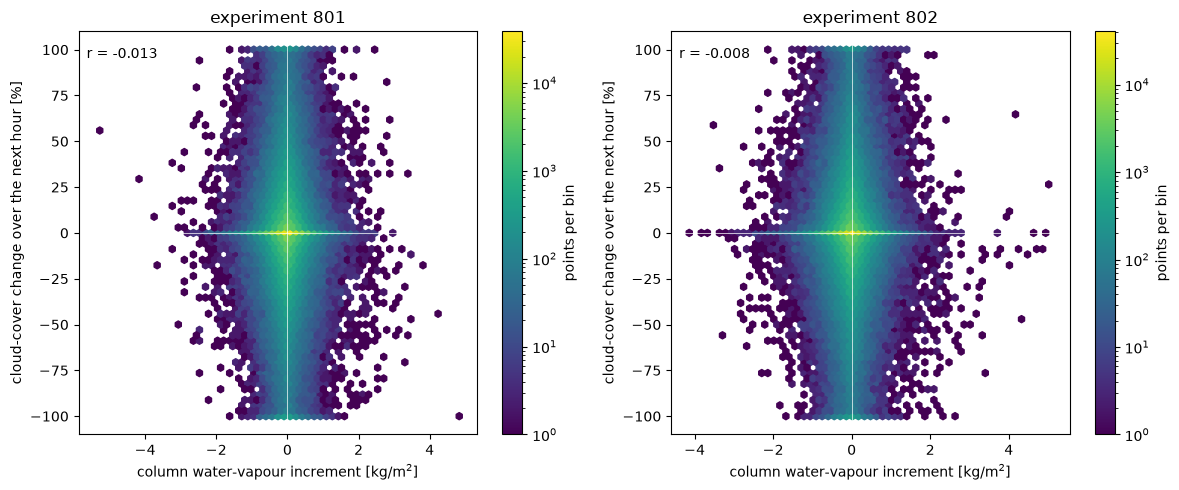

,exp,bin,mean,sem,count
0,801,"(-inf, -1.0]",0.120013,0.489500,2899
1,801,"(-1.0, -0.3]",-0.659397,0.133466,37143
2,801,"(-0.3, -0.05]",-1.104367,0.097050,65596
3,801,"(-0.05, 0.05]",-0.925660,0.088669,63019
4,801,"(0.05, 0.3]",-0.994312,0.094262,65489
5,801,"(0.3, 1.0]",-1.510947,0.142011,33277
6,801,"(1.0, inf]",-3.068897,0.583890,2577
7,802,"(-inf, -1.0]",-0.229529,0.517815,2630
8,802,"(-1.0, -0.3]",-0.726350,0.138258,36445
9,802,"(-0.3, -0.05]",-0.663758,0.097627,67110


In [16]:
fig, axes = plt.subplots(1, len(EXP_IDS), figsize=(6 * len(EXP_IDS), 5), squeeze=False)
for ax, exp_id in zip(axes.flat, EXP_IDS):
    sub = scatter_df[scatter_df["exp"] == exp_id]
    hb = ax.hexbin(sub["col_qv_increment"], sub["d_clct_next_hour"],
                   gridsize=60, mincnt=1, cmap="viridis", bins="log")
    plt.colorbar(hb, ax=ax, label="points per bin")
    ax.axhline(0, color="w", lw=0.5)
    ax.axvline(0, color="w", lw=0.5)
    ax.set_xlabel("column water-vapour increment [kg/m$^2$]")
    ax.set_ylabel("cloud-cover change over the next hour [%]")
    ax.set_title(f"experiment {exp_id}")
    if len(sub) > 2:
        r = np.corrcoef(sub["col_qv_increment"], sub["d_clct_next_hour"])[0, 1]
        ax.text(0.02, 0.96, f"r = {r:+.3f}", transform=ax.transAxes, va="top",
                bbox=dict(fc="w", alpha=0.7, ec="none"))
plt.tight_layout()
finish(fig, "qv_increment_vs_cloud_response.png")

# The overall correlation is dominated by the large number of points where nothing
# happens, so also bin by increment size, which is far more readable.
bins = [-np.inf, -1, -0.3, -0.05, 0.05, 0.3, 1, np.inf]
binned = (scatter_df
          .assign(bin=lambda d: pd.cut(d["col_qv_increment"], bins))
          .groupby(["exp", "bin"], observed=True)["d_clct_next_hour"]
          .agg(["mean", "sem", "count"])
          .reset_index())
binned


## 6. Cross-sections: where in space does the cycle put and remove cloud water?

Everything so far is an average over a region, which answers "how much" but not "where". Two
questions the averages cannot separate:

1. Does the model remove the water **in the same places** the assimilation added it — a local
   tug-of-war — or somewhere else entirely? A domain mean looks identical either way.
2. Do the corrections sit **inside the shallow layer near the ground**, capped by a temperature
   inversion, which is the fog and low-stratus situation this investigation is about? Or are they
   spread through the depth of the troposphere?

Both figures show the same four quantities in cycle order: the background, then the increment,
the settling step and the free hour. The three change panels share one symmetric colour scale, so
their magnitudes can be compared directly by eye. **Red means more, blue means less.**

The vertical section is drawn against real altitude with the terrain filled in, which is the
clearest way to see whether a correction is trapped beneath an inversion.

Set `XSEC_AGGREGATE = True` to average over all the selected cycles, which suppresses noise and
shows the systematic pattern, or `False` for a single cycle, which shows real structure that
averaging washes out. The two answer different questions and it is worth looking at both.


In [17]:
# ---------------------------- what to cut through ----------------------------
XSEC_EXP = "801"                        # which experiment
XSEC_VAR = "QC"                         # "T", "QV", "QC" or "RH"
XSEC_LEVEL = 70                         # model level for the maps; must be in LEVELS_OF_INTEREST
XSEC_TIME = datetime(2025, 10, 5, 8)    # the cycle used when XSEC_AGGREGATE is False
XSEC_AGGREGATE = False                  # True = mean over focus_times, False = one cycle
XSEC_BBOX = dict(lon=(5.5, 11.0), lat=(45.5, 48.0))    # Switzerland and surroundings
TRANSECT = ((45.90, 7.50), (47.60, 7.50))   # (lat, lon) south -> north: Alps, Plateau, Jura
N_TRANSECT = 300
XSEC_ZTOP = 6000.0                      # top of the vertical section [m]

# the four panels, in cycle order: (key, title, use a diverging colour scale)
PANELS = [("lff", "background", False),
          ("d_letkf", "increment (no model)", True),
          ("d_settle", "settling (~10 min model)", True),
          ("d_free", "free run (1 h model)", True)]


def xsec_fields(exp_id, times, var):
    """Mean over the given cycles of the four panel fields, plus geometry."""
    tot, z, n = {k: None for k, _, _ in PANELS}, None, 0
    lon = lat = hsurf = lev = None
    for t in times:
        st = cycle_states(exp_id, t)
        lon, lat, hsurf, lev = st["lon"], st["lat"], st["hsurf"], st["level"]
        z = st["z"].copy() if z is None else z + st["z"]
        for key, _, _ in PANELS:
            f = st[(key, var)]
            tot[key] = f.copy() if tot[key] is None else tot[key] + f
        n += 1
    if n == 0:
        raise RuntimeError("no cycles could be loaded for the cross-section")
    return {k: v / n for k, v in tot.items()}, lon, lat, hsurf, lev, z / n


def great_circle(p0, p1, n):
    """n points along the great circle from p0 to p1; returns lat, lon, distance [km]."""
    la0, lo0, la1, lo1 = map(np.deg2rad, [p0[0], p0[1], p1[0], p1[1]])
    d = np.arccos(np.clip(np.sin(la0) * np.sin(la1) +
                          np.cos(la0) * np.cos(la1) * np.cos(lo1 - lo0), -1, 1))
    f = np.linspace(0, 1, n)
    if d < 1e-12:
        return np.full(n, p0[0]), np.full(n, p0[1]), np.zeros(n)
    A, B = np.sin((1 - f) * d) / np.sin(d), np.sin(f * d) / np.sin(d)
    x = A * np.cos(la0) * np.cos(lo0) + B * np.cos(la1) * np.cos(lo1)
    y = A * np.cos(la0) * np.sin(lo0) + B * np.cos(la1) * np.sin(lo1)
    zz = A * np.sin(la0) + B * np.sin(la1)
    return (np.rad2deg(np.arctan2(zz, np.sqrt(x ** 2 + y ** 2))),
            np.rad2deg(np.arctan2(y, x)), d * 6371.0 * f)


def _unit_xyz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    return np.column_stack([np.cos(la) * np.cos(lo), np.cos(la) * np.sin(lo), np.sin(la)])


def nearest_cells(lon, lat, lon_t, lat_t):
    """Nearest model cell to each transect point, on the sphere."""
    return cKDTree(_unit_xyz(lat, lon)).query(_unit_xyz(lat_t, lon_t))[1]


def sym_limit(arrays, pct=99.0):
    """One symmetric colour limit shared by the change panels, so they stay comparable."""
    vals = np.concatenate([np.abs(a[np.isfinite(a)]).ravel() for a in arrays])
    v = np.nanpercentile(vals, pct) if vals.size else 1.0
    return v if v > 0 else 1.0


xsec_times = focus_times if XSEC_AGGREGATE else [XSEC_TIME]
fields, xlon, xlat, xhsurf, xlev, xz = xsec_fields(XSEC_EXP, xsec_times, XSEC_VAR)
xsec_tag = (f"mean of {len(xsec_times)} cycles" if XSEC_AGGREGATE
            else XSEC_TIME.strftime("%Y-%m-%d %H UTC"))
print(f"experiment {XSEC_EXP}, {XSEC_VAR}, {xsec_tag}; "
      f"{xlon.size} grid cells, levels {xlev.min()}-{xlev.max()}")


experiment 801, QC, 2025-10-05 08 UTC; 1147980 grid cells, levels 40-80


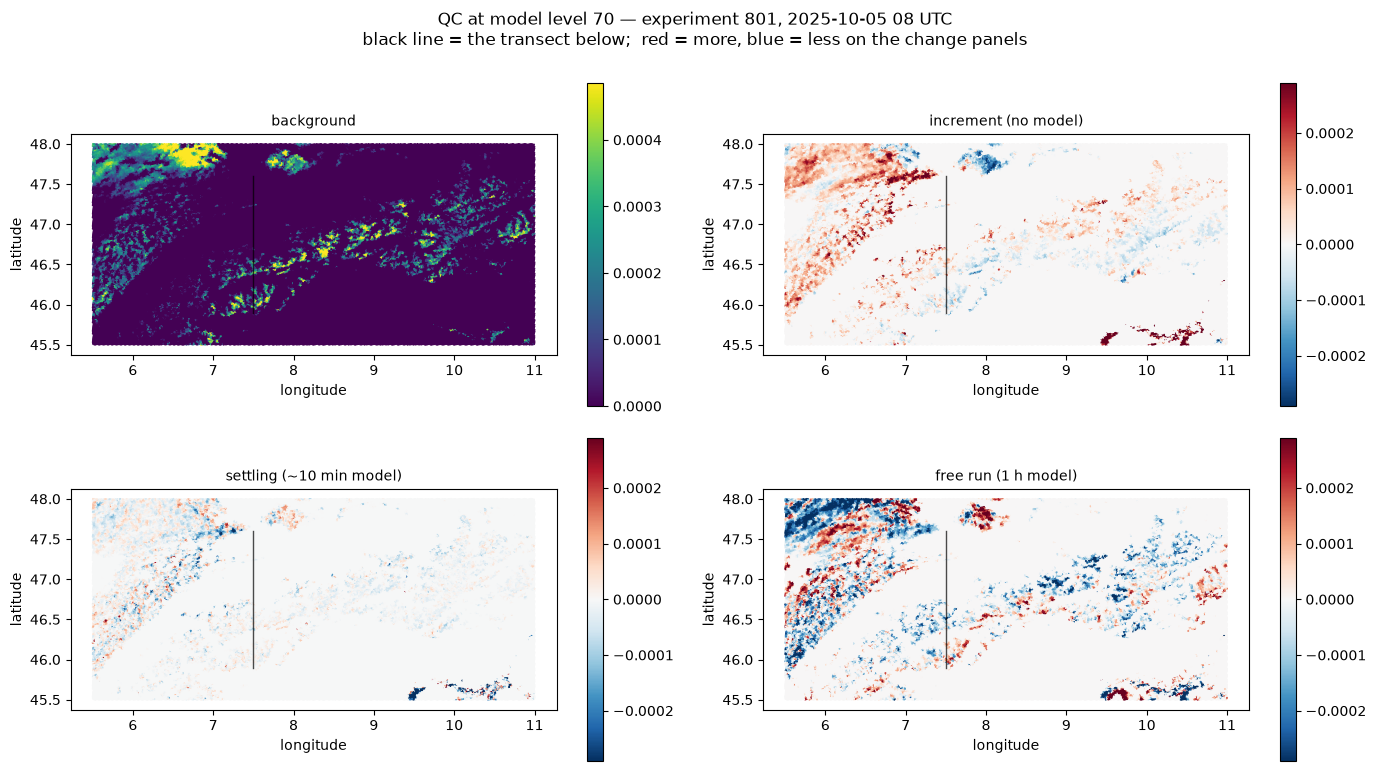

level 70: correlation between increment and settling = -0.692


In [18]:
# ------------------------- 6a. maps at one model level -------------------------
k = int(np.where(xlev == XSEC_LEVEL)[0][0])
inbox = ((xlon >= XSEC_BBOX["lon"][0]) & (xlon <= XSEC_BBOX["lon"][1]) &
         (xlat >= XSEC_BBOX["lat"][0]) & (xlat <= XSEC_BBOX["lat"][1]))

vlim = sym_limit([fields[key][k][inbox] for key, _, diverging in PANELS if diverging])

# 2x2 rather than one row: the box is about twice as wide as it is tall and the aspect
# ratio is fixed, so a single row leaves the panels small.
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
lat_t, lon_t, _ = great_circle(*TRANSECT, N_TRANSECT)

for ax, (key, label, diverging) in zip(axes.flat, PANELS):
    v = fields[key][k][inbox]
    finite = v[np.isfinite(v)]
    if diverging:
        sc = ax.scatter(xlon[inbox], xlat[inbox], c=v, s=2.0, cmap="RdBu_r",
                        vmin=-vlim, vmax=vlim, linewidths=0)
    else:
        sc = ax.scatter(xlon[inbox], xlat[inbox], c=v, s=2.0, cmap="viridis", vmin=0,
                        vmax=(np.nanpercentile(finite, 99) if finite.size else 1.0),
                        linewidths=0)
    plt.colorbar(sc, ax=ax, shrink=0.9)
    ax.plot(lon_t, lat_t, "k-", lw=1.0, alpha=0.7)      # the transect of 6b
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect("equal")

plt.suptitle(f"{XSEC_VAR} at model level {XSEC_LEVEL} — experiment {XSEC_EXP}, {xsec_tag}\n"
             f"black line = the transect below;  red = more, blue = less on the change panels")
plt.tight_layout()
finish(fig, f"xsec_maps_{XSEC_VAR}_lev{XSEC_LEVEL}_{XSEC_EXP}"
            f"{'_mean' if XSEC_AGGREGATE else XSEC_TIME.strftime('_%Y%m%d%H')}.png")

# Does the model undo the increment where it was put, or somewhere else? A strongly
# negative correlation means a local tug-of-war; near zero means redistribution.
a, b = fields["d_letkf"][k][inbox], fields["d_settle"][k][inbox]
ok = np.isfinite(a) & np.isfinite(b)
print(f"level {XSEC_LEVEL}: correlation between increment and settling = "
      f"{np.corrcoef(a[ok], b[ok])[0, 1]:+.3f}")


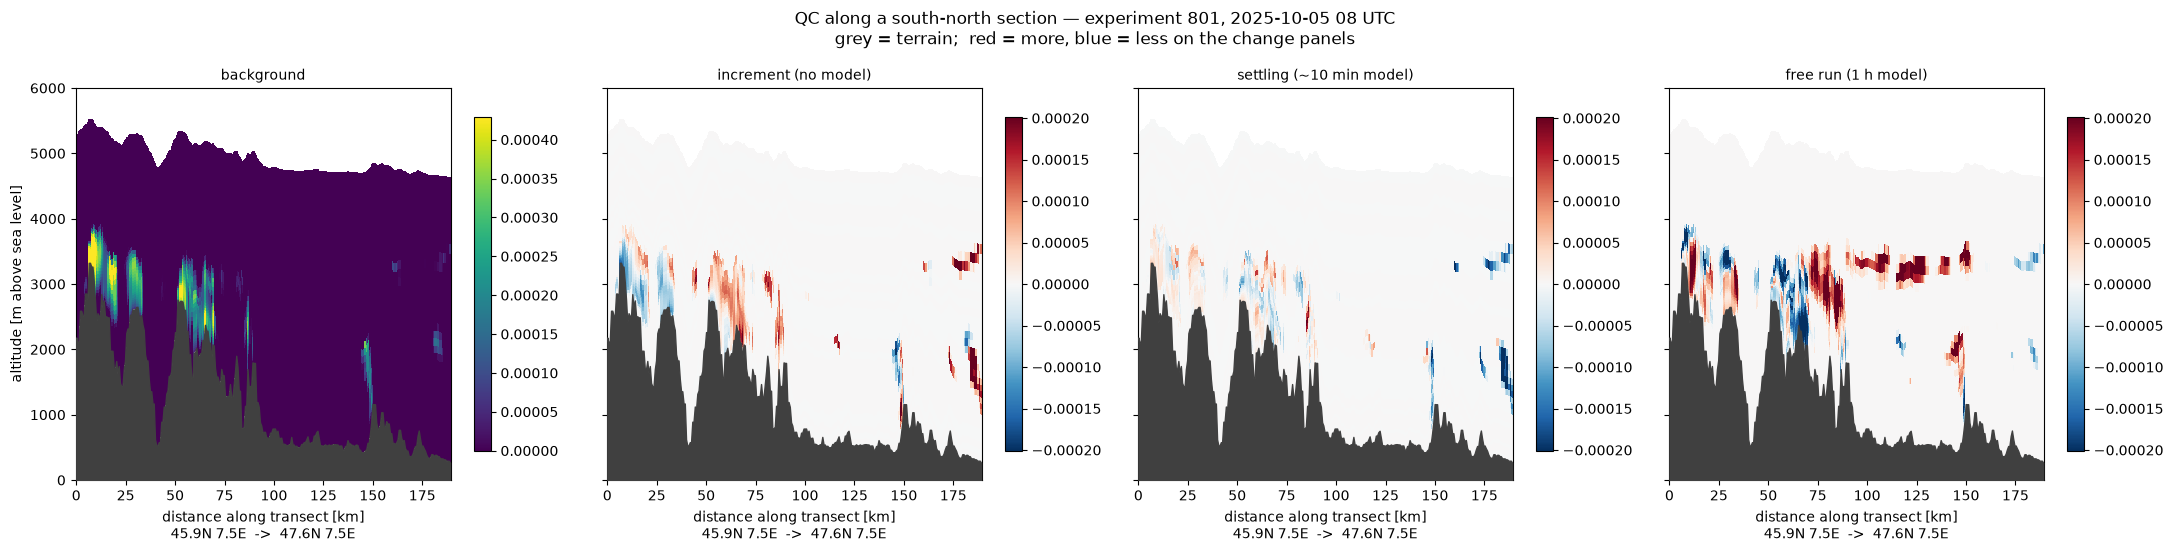

share of each step's magnitude below 1500 m above ground, along the transect:
  increment (no model)          87.6%
  settling (~10 min model)      83.5%
  free run (1 h model)          71.9%


In [19]:
# ------------------ 6b. vertical section against real altitude ------------------
lat_t, lon_t, dist_km = great_circle(*TRANSECT, N_TRANSECT)
idx = nearest_cells(xlon, xlat, lon_t, lat_t)

z_sec = xz[:, idx]                 # height of each level along the transect [m]
terrain = xhsurf[idx]              # ground height [m]
dist2d = np.broadcast_to(dist_km, z_sec.shape)

vlim = sym_limit([fields[key][:, idx] for key, _, diverging in PANELS if diverging])

fig, axes = plt.subplots(1, 4, figsize=(22, 5.6), sharex=True, sharey=True)
for ax, (key, label, diverging) in zip(axes, PANELS):
    v = fields[key][:, idx]
    finite = v[np.isfinite(v)]
    if diverging:
        pc = ax.pcolormesh(dist2d, z_sec, v, shading="auto", cmap="RdBu_r",
                           vmin=-vlim, vmax=vlim)
    else:
        pc = ax.pcolormesh(dist2d, z_sec, v, shading="auto", cmap="viridis", vmin=0,
                           vmax=(np.nanpercentile(finite, 99) if finite.size else 1.0))
    plt.colorbar(pc, ax=ax, shrink=0.85)
    ax.fill_between(dist_km, 0, terrain, color="0.25", zorder=5)    # terrain
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(f"distance along transect [km]\n"
                  f"{TRANSECT[0][0]:.1f}N {TRANSECT[0][1]:.1f}E  ->  "
                  f"{TRANSECT[1][0]:.1f}N {TRANSECT[1][1]:.1f}E")
    ax.set_ylim(0, XSEC_ZTOP)
axes[0].set_ylabel("altitude [m above sea level]")
plt.suptitle(f"{XSEC_VAR} along a south-north section — experiment {XSEC_EXP}, {xsec_tag}\n"
             f"grey = terrain;  red = more, blue = less on the change panels")
plt.tight_layout()
finish(fig, f"xsec_vertical_{XSEC_VAR}_{XSEC_EXP}"
            f"{'_mean' if XSEC_AGGREGATE else XSEC_TIME.strftime('_%Y%m%d%H')}.png")

# Is each step concentrated in the lowest 1.5 km, i.e. the layer where fog and low
# stratus live? Measured along this transect only.
agl = z_sec - terrain[None, :]
print(f"share of each step's magnitude below 1500 m above ground, along the transect:")
for key, label, diverging in PANELS:
    if not diverging:
        continue
    v = np.abs(fields[key][:, idx])
    print(f"  {label:28s} {100.0 * np.nansum(np.where(agl <= 1500.0, v, 0.0)) / np.nansum(v):5.1f}%")


## 7. Summary

### Output files

All in `figures/spindown_decomposition/`.

| file | contents |
|---|---|
| `cycle_decomposition.csv` | per-cycle regional-mean cloud cover at the three stages |
| `decomposition_table.csv`, `morning_801_802_table.csv` | the two steps, summarised |
| `moisture_budget_columns.csv`, `moisture_budget_table.csv` | column water budget per step, kg/m² |
| `clct_timeseries_domain.png` | cloud cover through the week |
| `diag_vars_three_way_split.png` | temperature, vapour, cloud water, humidity: states and steps |
| `supersaturation_by_stage.png` | saturated fraction, and which step creates it |
| `qv_increment_vs_cloud_response.png` | moisture correction against the next hour's cloud change |
| `xsec_maps_*.png`, `xsec_vertical_*.png` | where in space each step acts |

### Reading the results

- Judge every mean against its standard error before calling it systematic.
- `d_int` in section 1 is constrained by the arithmetic of a closed cycle and is not evidence about
  the model. Use `d_ana`, and the difference between the two experiments, instead.
- Make mechanism arguments on temperature, water vapour and cloud water, where the assimilation step
  is exactly separable, and only then relate them to cloud cover.
- A difference in cloud cover between the two experiments says which one is *cloudier*, not which
  one is *better*. Deciding that requires observations, which are outside this notebook.

### Open questions this notebook cannot close

- Whether the analysis is already too cloudy when it is made, or whether the model generates the
  excess during the first hour. Separating these needs the analysis verified against station
  observations and compared with the 1 h forecast.
- Whether the screen-level temperature or the screen-level humidity is responsible, which needs an
  experiment withholding one but not the other.
- How the excess evolves beyond one hour: these experiments ran the assimilation cycle only, with no
  longer forecasts, so the 4-6 hour decay seen in routine verification cannot be reproduced here.
